<a href="https://colab.research.google.com/github/miajags/EMSC2010-W7-penguins/blob/main/EMSC2010_W7_P1_NB1_air_pressure_probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W7-P1-NB1

We will test if the air pressures inside and outside the building are the same.

The whole class will collect data using Phyphox (see the *Pressure* option), with each person measuring one inside pressure and one outside pressure. These data will be our measured air pressure samples.

Use the ```PyMC``` code we developed in the previous session (see notebook ```EMSC2010-W7-L1-NB3``` to estimate the posterior distributions for the mean atmospheric pressures inside and outside the building.

In [27]:
#imports yay

import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

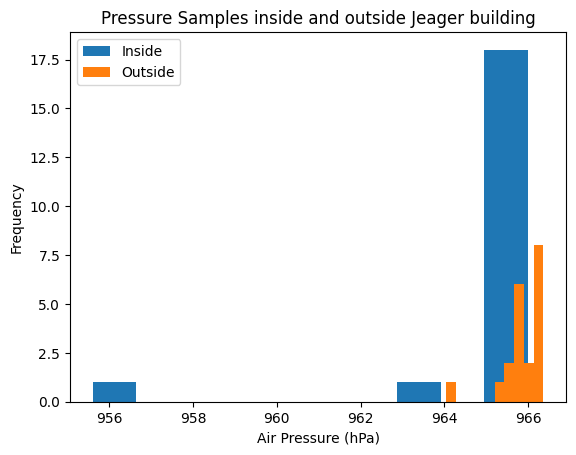

In [28]:
data_in = np.array([965.784, 965.07, 965.90, 965.993, 965.765, 965.786, 955.604, 965.057, 965.50, 965.390, 965.302, 965.901, 963.623, 965.388, 965.5, 965.910, 965.564, 965.893, 965.735, 965.537])
#inside Jeager air pressure

data_out = np.array([966.176, 965.453, 966.25, 966.363, 966.15, 966.085, 965.649, 965.414, 966.172, 965.750, 965.673, 966.257, 964.034, 965.763, 965.85, 966.264, 966.111, 965.864, 966.291, 965.867])
#outside Jeager pressure data

plt.hist(data_in)
plt.hist(data_out)
plt.xlabel('Air Pressure (hPa)')
plt.ylabel('Frequency')
plt.legend(['Inside', 'Outside'])
plt.title('Pressure Samples inside and outside Jeager building')
plt.show()

<Axes: title={'center': 'mu'}>

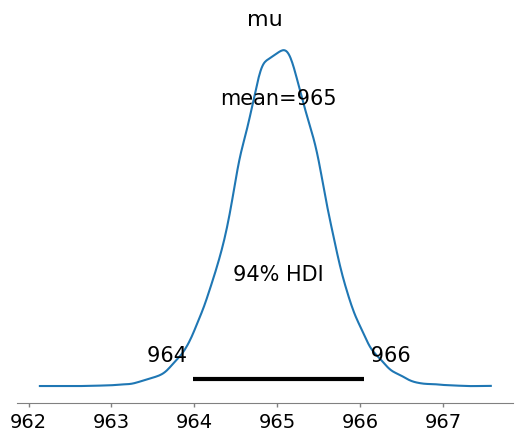

In [29]:
#informative (sampling) inside pressure model

with pm.Model() as inside_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu = pm.Normal("mu", mu=1000, sigma=100)
    #sigma is our standard deviation, plus or minus 100 hPa around the mean
    #mean guess 1,000 cause air pressure knowledge

    # Prior for std of heights — HalfNormal with a standard deviation of 20.
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data_in)

    # Obtain 20,000 samples from the posterior
    trace_in = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_in, var_names=["mu"])

<Axes: title={'center': 'mu'}>

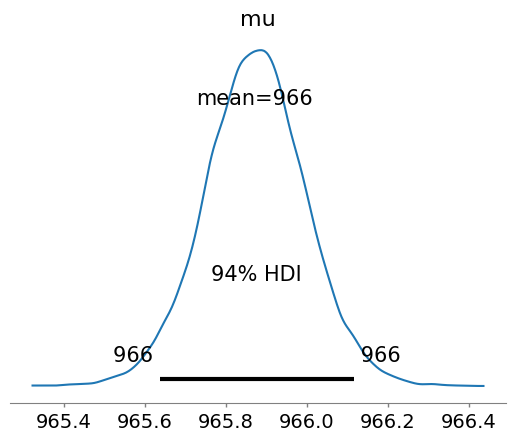

In [30]:
#informative (sampling) outside pressure model

with pm.Model() as outside_model:

    # Prior for the mean — Normal centered at your best prior guess with sigma representing the uncertainty in that guess
    mu = pm.Normal("mu", mu=1000, sigma=100)
    #sigma is our standard deviation, plus or minus 100 hPa around the mean
    #mean guess 1,000 cause air pressure knowledge

    # Prior for std of heights — HalfNormal with a standard deviation of 20.
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data_out)

    # Obtain 20,000 samples from the posterior
    trace_out = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_out, var_names=["mu"])

Are the air pressures different or not?

- We can use subtraction
- generate random values from data_in and data_out, subtract them, plot the difference

In [31]:
#Extract the prosterior samples as a numpy array

#inside
mu_samples_inside = trace_in.posterior["mu"].values.flatten()

#outside
mu_samples_outside = trace_out.posterior["mu"].values.flatten()

Text(0.5, 1.0, 'Difference in Inside-Outside Atmospheric Pressure Samples')

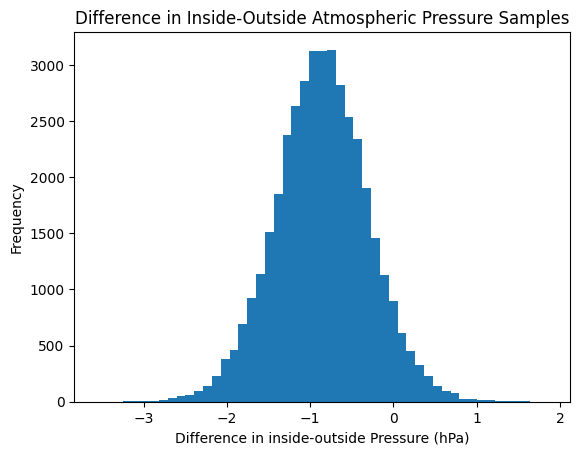

In [32]:
#subtracting to find difference
mu_diff = mu_samples_inside - mu_samples_outside

#plotting inside-outside difference
plt.hist(mu_diff, bins=51);
plt.xlabel('Difference in inside-outside Pressure (hPa)')
plt.ylabel('Frequency')
plt.title('Difference in Inside-Outside Atmospheric Pressure Samples')

If there was NO difference in air pressure, then the distribution would be 0.



HDI = Highest Density Interval

In [33]:
#95% probability that the difference in air pressure is 0

az.hdi(mu_diff, hdi_prob=0.95) #finds middle 95% of the difference distribution histogram above - aka 95% probability

#0 is in the 95% probability interval below.

array([-1.98316729,  0.23908944])

0 is in the interval above (0.2905...), meaning 0 is in the 95% probability interval of inside-outside difference

95% probability that inside-outside difference is 0.
- Therefore there is no difference in air pressure.